In [1]:
import pandas as pd 
import networkx as nx 
from node2vec import Node2Vec 
import umap 
import warnings 



In [2]:
# load the and concat the different datasets we created (because of runtime errors) 

df1 = pd.read_csv("../exported_data/graph_edges_dataset.csv")
df2 = pd.read_csv("../exported_data/graph_edges_dataset_2.csv")
df3 = pd.read_csv("../exported_data/graph_edges_safe_dataset.csv")
df4 = pd.read_csv("../exported_data/graph_edges_safe_dataset_3.csv")

edges_df = pd.concat([df1,df2,df3,df4],axis = 0)


In [ ]:
origins_df = pd.read_csv("../exported_data/wallet_genesis_origins_enriched.csv")
crawled_wallets = set(origins_df['Wallet'].tolist())

# Keep only edges where both receiver and senderf are taken
edges_df = edges_df[
    edges_df['Sender'].isin(crawled_wallets) & 
    edges_df['Receiver'].isin(crawled_wallets)
].reset_index(drop=True)

all_wallets_filtered = set(edges_df['Sender'].tolist() + edges_df['Receiver'].tolist())
print(f"Edges after filtering to crawled wallets: {len(edges_df):,}")
print(f"Unique wallets remaining:                 {len(all_wallets_filtered):,}")
print(f"All wallets now have genesis data:        ")


Edges after filtering to crawled wallets: 29,637
Unique wallets remaining:                 11,100
All wallets now have genesis data:        


In [ ]:
import numpy as np
import pandas as pd

# Build ground truth
origins_df = pd.read_csv("../exported_data/wallet_genesis_origins_enriched.csv")
wallet_blocktime = origins_df.set_index('Wallet')['blockTime'].to_dict()
wallet_funding   = origins_df.set_index('Wallet')['Funding_Amount'].to_dict()

funder_counts    = origins_df['Funder_Wallet'].value_counts()
malicious_funders = funder_counts[funder_counts > 2].index.tolist()
malicious_funders = [f for f in malicious_funders if str(f) not in ('Unknown', 'nan')]

puppet_wallets = set(origins_df[origins_df['Funder_Wallet'].isin(malicious_funders)]['Wallet'].tolist())
print(f"Ground Truth: {len(puppet_wallets)} confirmed Sybil puppet wallets")

# Tag every token as scam or safe using puppet_wallets
all_tokens = edges_df['Token'].unique()

def token_has_scam(token):
    wallets = set(edges_df[edges_df['Token'] == token][['Sender','Receiver']].values.flatten())
    return len(wallets & puppet_wallets) > 0

scam_tokens = np.array([t for t in all_tokens if token_has_scam(t)])
safe_tokens = np.array([t for t in all_tokens if not token_has_scam(t)])
print(f"Scam Tokens: {len(scam_tokens)} | Safe Tokens: {len(safe_tokens)}")

# Stratified 80/20 split within EACH bucket
np.random.seed(42)
np.random.shuffle(scam_tokens)
np.random.shuffle(safe_tokens)

scam_split = int(len(scam_tokens) * 0.8)
safe_split = int(len(safe_tokens) * 0.8)

train_tokens = set(list(scam_tokens[:scam_split]) + list(safe_tokens[:safe_split]))
test_tokens  = set(list(scam_tokens[scam_split:]) + list(safe_tokens[safe_split:]))

train_edges = edges_df[edges_df['Token'].isin(train_tokens)].reset_index(drop=True)
test_edges  = edges_df[edges_df['Token'].isin(test_tokens)].reset_index(drop=True)

print(f"\nScam Tokens  -> Train: {scam_split} | Test: {len(scam_tokens)-scam_split}")
print(f"Safe Tokens  -> Train: {safe_split} | Test: {len(safe_tokens)-safe_split}")
print(f"Train Edges: {len(train_edges)} | Test Edges: {len(test_edges)}")


Ground Truth: 1730 confirmed Sybil puppet wallets
Scam Tokens: 51 | Safe Tokens: 67

Scam Tokens  -> Train: 40 | Test: 11
Safe Tokens  -> Train: 53 | Test: 14
Train Edges: 23901 | Test Edges: 5736


**Extracting wallet metadata for clustering based on funding amount etc.**


The idea is as follows : 
If we only search the Red nodes, we leave a massive blind spot that smart scammers could exploit. A smart scammer would fund 50 wallets, use them to snipe the pool, and then purposely never transfer the tokens manually so that our graph colors them innocent "Cyan".

By running the Genesis search on all interacting wallets, we strip away the token-layer completely and expose their true origin point.

In [6]:
from dotenv import load_dotenv
import os 
load_dotenv(dotenv_path='../.env')
rpc_url = f"https://mainnet.helius-rpc.com/?api-key={os.getenv('HELIUS_API_KEY')}"

# Extract every single unique wallet (either sender or receiver)
senders = edges_df['Sender'].unique()
receivers = edges_df['Receiver'].unique()
unique_wallets = pd.Series(list(senders) + list(receivers)).unique()

print(f"Backtracking for {len(unique_wallets)} unique wallets.")


Backtracking for 11100 unique wallets.


In [7]:
import pandas as pd
import requests
import time
import os
from dotenv import load_dotenv

wallet_origins = []

already_processed = set()
if os.path.exists("../exported_data/wallet_genesis_origins_backup.csv"):
    # Load the backup file
    backup_df = pd.read_csv("../exported_data/wallet_genesis_origins_backup.csv")
    already_processed = set(backup_df['Wallet']) 
    
    # resume from backup
    wallet_origins = backup_df.to_dict('records') 
    print(f"Resuming from backup! Skipping {len(already_processed)} already-processed wallets...\n")
else:
    wallet_origins = []
for idx, wallet in enumerate(unique_wallets):
    
    # skip done
    if wallet in already_processed:
        continue 
        
    oldest_sig = None
    genesis_sig = None
    
    for page in range(50):
        payload = {"jsonrpc": "2.0", "id": 1, "method": "getSignaturesForAddress", "params": [wallet, {"limit": 1000}]}
        if oldest_sig: payload["params"][1]["before"] = oldest_sig
            
        res = requests.post(rpc_url, json=payload).json()
        batch = res.get('result', [])
        
        if not batch: break 
            
        genesis_sig = batch[-1]['signature']
        oldest_sig = genesis_sig
        time.sleep(0.1)
        
    if not genesis_sig: continue
        
    print(f"  -> Origin Reached: {genesis_sig[:15]}... Extracting Source Funding...")
    
    tx_payload = {"jsonrpc": "2.0", "id": 1, "method": "getTransaction", "params": [genesis_sig, {"encoding": "jsonParsed", "maxSupportedTransactionVersion": 0}]}
    tx_res = requests.post(rpc_url, json=tx_payload).json()
    
    meta = tx_res.get('result', {}).get('meta') if tx_res.get('result') else None
    funder = "Unknown"
    
    if meta and not meta.get('err'):
        pre_bals = meta.get('preBalances', [])
        post_bals = meta.get('postBalances', [])
        acct_keys = tx_res['result']['transaction']['message']['accountKeys']
        addresses = [k['pubkey'] if isinstance(k, dict) else k for k in acct_keys]
        
        biggest_loss, funder_index = 0, -1
        for i in range(len(pre_bals)):
            loss = pre_bals[i] - post_bals[i]
            if loss > biggest_loss:
                biggest_loss = loss
                funder_index = i
                
        if funder_index != -1: funder = addresses[funder_index]
                
    print(f"Funded By: {funder}")
    
    wallet_origins.append({
        "Wallet": wallet,
        "Genesis_Signature": genesis_sig,
        "Funder_Wallet": funder
    })

# Save the Meta-Graph Dataset
origins_df = pd.DataFrame(wallet_origins)
origins_df.to_csv("../exported_data/wallet_genesis_origins.csv", index=False)

display(origins_df.head(10))


Resuming from backup! Skipping 2697 already-processed wallets...



KeyboardInterrupt: 

In [8]:
import pandas as pd
import requests
import time
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path='../.env')
rpc_url = f"https://mainnet.helius-rpc.com/?api-key={os.getenv('HELIUS_API_KEY')}"

wallet_origins = []

print(f"Starting backcrawl {len(unique_wallets)} wallets...")

for idx, wallet in enumerate(unique_wallets):
    
    oldest_sig = None
    genesis_sig = None
    
    # 1. Walk backward (1 page at a time)
    for page in range(50):
        payload = {"jsonrpc": "2.0", "id": 1, "method": "getSignaturesForAddress", "params": [wallet, {"limit": 1000}]}
        if oldest_sig: payload["params"][1]["before"] = oldest_sig
        
        try:
            res = requests.post(rpc_url, json=payload).json()
            if 'error' in res and res['error'].get('code') == 429:
                print("  [!] Rate limited. Sleeping 5 seconds...")
                time.sleep(5)
                res = requests.post(rpc_url, json=payload).json() # retry
        except Exception as e:
            break
            
        batch = res.get('result', [])
        if not batch: break 
            
        genesis_sig = batch[-1]['signature']
        oldest_sig = genesis_sig
        time.sleep(0.15) # rate limit
        
    if not genesis_sig: 
        print(f"Failed to crawl history for {wallet[:8]}")
        continue
        
    # 2. Get Funder 
    tx_payload = {"jsonrpc": "2.0", "id": 1, "method": "getTransaction", "params": [genesis_sig, {"encoding": "jsonParsed", "maxSupportedTransactionVersion": 0}]}
    
    try:
        tx_res = requests.post(rpc_url, json=tx_payload).json()
        if 'error' in tx_res and tx_res['error'].get('code') == 429:
            time.sleep(5)
            tx_res = requests.post(rpc_url, json=tx_payload).json()
    except:
        pass
        
    meta = tx_res.get('result', {}).get('meta') if tx_res and tx_res.get('result') else None
    funder = "Unknown"
    
    if meta and not meta.get('err'):
        pre_bals = meta.get('preBalances', [])
        post_bals = meta.get('postBalances', [])
        acct_keys = tx_res['result']['transaction']['message']['accountKeys']
        addresses = [k['pubkey'] if isinstance(k, dict) else k for k in acct_keys]
        
        biggest_loss, funder_index = 0, -1
        for i in range(len(pre_bals)):
            loss = pre_bals[i] - post_bals[i]
            if loss > biggest_loss:
                biggest_loss = loss
                funder_index = i
                
        if funder_index != -1: 
            funder = addresses[funder_index]
        else:
            funder = addresses[0]
                
    wallet_origins.append({
        "Wallet": wallet,
        "Genesis_Signature": genesis_sig,
        "Funder_Wallet": funder
    })
    
    if (idx + 1) % 50 == 0:
        print(f"Processed: {idx+1} / {len(unique_wallets)}")
        pd.DataFrame(wallet_origins).to_csv("../exported_data/wallet_genesis_origins_backup.csv", index=False)# checkpoint

# Final Save
origins_df = pd.DataFrame(wallet_origins)
origins_df.to_csv("../exported_data/wallet_genesis_origins.csv", index=False)
print(f"Crawl Complete! Successfully extracted {len(origins_df)} origins.")
display(origins_df.head())


Starting backcrawl 11100 wallets...


KeyboardInterrupt: 

In [5]:
G_train = nx.from_pandas_edgelist(train_edges, source = "Sender" , target = "Receiver" , create_using = nx.DiGraph())
train_wallets = list(G_train.nodes())


In [15]:
pip install --upgrade debugpy

165.41s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: debugpy
    Found existing installation: debugpy 1.6.7
    Uninstalling debugpy-1.6.7:
      Successfully uninstalled debugpy-1.6.7
Note: you may need to restart the kernel to use updated packages.


In [6]:
# node2vec random walks
node2vec = Node2Vec(G_train,dimensions =64 , walk_length= 30, num_walks = 100 , workers = 2 , quiet= True)
model = node2vec.fit(window = 10, min_count = 1 , batch_words = 4)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [7]:
embeddings = np.array([model.wv[str(w)] for w in train_wallets])

In [8]:
# UMAP 3D from 64d embeddings
print(f"Umap Topology: ")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=67)
umap_embeddings = reducer.fit_transform(embeddings)
import pickle
with open('../exported_data/umap_reducer.pkl', 'wb') as f:
    pickle.dump(reducer, f)


Umap Topology: 


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [9]:
from sklearn.neighbors import NearestNeighbors
#
# We deliberately avoid using raw UMAP coordinates (X, Y, Z) as model features.
# UMAP is a non-parametric, stochastic projection — the absolute position of a
# wallet in 2D/3D space is arbitrary and will differ across graphs and runs.
# A scam wallet at (0.3, 0.7, 0.1) in the train graph has no meaningful
# correspondence to any coordinate in the test graph.
#
# Instead, we extract TOPOLOGY-AWARE statistics from the UMAP neighbourhood:
#
#   local_density     = 1 / mean_kNN_distance
#     → scam wallets cluster tightly (low kNN dist → high density)
#     → organic wallets spread out (high kNN dist → low density)
#
#   avg_neighbor_dist = mean distance to 10 nearest neighbours
#     → inverse of density; kept separately as a complementary signal
#
# These are RELATIVE, graph-agnostic features — they capture HOW CLUSTERED
# a wallet is in embedding space, not WHERE it sits. This transfers across
# graphs because scam behaviour (tight clustering) is consistent regardless
# of the specific token or run.
# 
nbrs = NearestNeighbors(n_neighbors=10, radius=0.5).fit(umap_embeddings)
distances, _ = nbrs.kneighbors(umap_embeddings)

local_density      = 1 / (distances.mean(axis=1) + 1e-6)  
avg_neighbor_dist  = distances.mean(axis=1)               


In [10]:
print(local_density)
print(avg_neighbor_dist)

[ 17.61525319  27.7163228   10.74023719 ...  54.30643419 264.13387716
 120.79176901]
[0.05676798 0.03607882 0.09310681 ... 0.01841302 0.00378496 0.00827771]


In [11]:
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# train graph
G_train = nx.from_pandas_edgelist(train_edges, source="Sender", target="Receiver", create_using=nx.DiGraph())

# pagerank
pageranks = nx.pagerank(G_train, alpha=0.85)

# in/out degrees
in_degrees  = dict(G_train.in_degree())
out_degrees = dict(G_train.out_degree())

# clustering coeff
clustering_coeffs = nx.clustering(G_train.to_undirected())

# avg amount received
wallet_amounts = train_edges.groupby('Receiver')['Amount'].mean().to_dict()

# send ratio (senders vs receivers)
wallet_send_ratio = {
    w: out_degrees.get(w,0) / max(in_degrees.get(w,0) + out_degrees.get(w,0), 1)
    for w in train_wallets
}

# local density from kNN
nbrs = NearestNeighbors(n_neighbors=10).fit(umap_embeddings)
distances, _ = nbrs.kneighbors(umap_embeddings)
local_density     = 1 / (distances.mean(axis=1) + 1e-6)
avg_neighbor_dist = distances.mean(axis=1)

wallet_blocktime = origins_df.set_index('Wallet')['blockTime'].to_dict()
wallet_funding   = origins_df.set_index('Wallet')['Funding_Amount'].to_dict()
print("features computed")


features computed


{'3ucNos4NbumPLZNWztqGHNFFgkHeRMBQAVemeeomsUxv': 1729515663,
 '8ekCy2jHHUbW2yeNGFWYJT9Hm9FW7SvZcZK66dSZCDiF': 1713924220,
 'Eb1DdWzQqXbdSY4ay8ms9u6cRYoDNhFtqm4K2QTCkms3': 1711656530,
 'FGQoLafigpyVb7mLa6pvsDDpDaEE3JetrzQoAggTo3n7': 1710274105,
 '8FnX3xo2yYw3EUE6w3nQA4GfXGS9wpK6oj3veJpbFzLo': 1705451628,
 'FksffEqnBRixYGR791Qw2MgdU7zNCpHVFYBL4Fa4qVuH': 1709294285,
 'MfDuWeqSHEqTFVYZ7LoexgAK9dxk7cy4DFJWjWMGVWa': 1718117801,
 '2nyC6jF1Hmjmth9AD2HbxiDhPm8x4FXWLq6FtRbVBUus': 1710664072,
 '7wYJVD8iXmMQjND1fwi1hPr68QwruVVtirbotyJZXaVH': 1705643338,
 'CYbD9RaToYMtWKA7QZyoLahnHdWq553Vm62Lh6qWtuxq': 1730672535,
 'Gsu4WmGJf9z4RWiQ9onE9u29rSvh5XsAkVwUJ2bLrGQb': 1735010087,
 'DJNtGuBGEQiUCWE8F981M2C3ZghZt2XLD8f2sQdZ6rsZ': 1729079753,
 '6n9VhCwQ7EwK6NqFDjnHPzEk6wZdRBTfh43RFgHQWHuQ': 1730992161,
 'EmDewJpfQaxWqxthX1FUyBCCPNGt8Ac5ek4M4pnGTgxC': 1711698190,
 'DB3sUCP2H4icbeKmK6yb6nUxU5ogbcRHtGuq7W2RoRwW': 1705684829,
 'JD6rVaerbyz6wjQ433nrw6bFTgFrp46MiYmi8EtUAfsG': 1705684559,
 '2kfQuYG2FVZL2RqqKEttcda

In [12]:
train_features = []
for i, wallet in enumerate(train_wallets):
    train_features.append([
        #umap_embeddings[i][0], umap_embeddings[i][1], umap_embeddings[i][2],
        pageranks.get(wallet, 0),
        in_degrees.get(wallet, 0),
        out_degrees.get(wallet, 0),
        clustering_coeffs.get(wallet, 0),
        wallet_send_ratio.get(wallet,0) ,
        local_density[i],
        avg_neighbor_dist[i],
        wallet_blocktime.get(wallet, 1704067200),
        wallet_funding.get(wallet, 0.5),
    ])
train_df = pd.DataFrame(train_features,
    columns=['PageRank','In_Degree','Out_Degree','Clustering','Wallet_send_ratio','local_dens','avg_neigb_dist','BlockTime', 'FundingAmount'
])
train_df['Wallet'] = train_wallets
print(f"Training Feature Matrix Shape: {train_df.shape}")
train_df.to_csv("../data_extraction/train_df.csv")

Training Feature Matrix Shape: (9306, 10)


In [13]:
train_features

[[6.572747712426747e-05,
  1,
  1,
  0,
  0.5,
  17.615253189821196,
  0.056767982496251625,
  1729515663,
  12.0747],
 [0.0010325584105285565,
  12,
  1,
  0.030303030303030304,
  0.07692307692307693,
  27.716322796080522,
  0.03607882225338399,
  1709955820,
  0.190159],
 [5.6156383827926754e-05,
  0,
  21,
  0,
  1.0,
  10.74023719003272,
  0.09310681338498107,
  1714202210,
  -0.002967],
 [5.843521556515073e-05,
  1,
  0,
  0,
  0.0,
  54.52667295303879,
  0.018338648209624893,
  1707985374,
  0.395425],
 [5.843521556515073e-05,
  1,
  0,
  0,
  0.0,
  13.594836437862721,
  0.07355633955098709,
  1714640560,
  19.791],
 [5.6156383827926754e-05,
  0,
  2,
  0,
  1.0,
  16.099980937953696,
  0.062110874781331246,
  1711987082,
  0.464663],
 [8.008411706877854e-05,
  1,
  0,
  0,
  0.0,
  10.0987907251529,
  0.09902075688315984,
  1706180633,
  1.5675],
 [8.489528612701917e-05,
  2,
  8,
  0.022222222222222223,
  0.8,
  13.225274846225453,
  0.07561179532012176,
  1710535858,
  0.1524

In [14]:
#normalise -- all 7 features 
from sklearn.preprocessing import MinMaxScaler

feature_cols = ['PageRank', 'In_Degree', 'Out_Degree','Wallet_send_ratio','local_dens','avg_neigb_dist','BlockTime', 'FundingAmount']
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols].values)


In [15]:
import torch
from torch_geometric.data import Data
import numpy as np

# wallet -> index mapping
node_wallets   = train_df["Wallet"].tolist()
wallet_mapping = {wallet: i for i, wallet in enumerate(node_wallets)}

# edge index
src = train_edges['Sender'].map(wallet_mapping)
tgt = train_edges['Receiver'].map(wallet_mapping)
valid = src.notna() & tgt.notna()
edge_index = torch.tensor(
    np.vstack([src[valid].astype(int).values, tgt[valid].astype(int).values]),
    dtype=torch.long)

# features
feature_cols = ['PageRank', 'In_Degree', 'Out_Degree','Wallet_send_ratio','local_dens','avg_neigb_dist','BlockTime', 'FundingAmount']

x = torch.tensor(train_df[feature_cols].values, dtype=torch.float)

# labels
real_labels = [1 if w in puppet_wallets else 0 for w in node_wallets]
y = torch.tensor(real_labels, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

print("data object ready")
print("-" * 50)
print(f"Nodes:    {data.num_nodes}")
print(f"Edges:    {data.num_edges}")
print(f"Features: {data.num_node_features}")
print(f"Scam labels: {y.sum().item()} / {data.num_nodes}")


data object ready
--------------------------------------------------
Nodes:    9306
Edges:    23901
Features: 8
Scam labels: 1612 / 9306


In [16]:
import torch

# Total number of nodes
num_nodes = len(data.y)

#  Option A: use ALL nodes (if all have labels) 
indices = torch.randperm(num_nodes)  # shuffled indices

#  Option B: only use LABELED nodes (skip -1 or NaN labels) 
labeled_mask = data.y != -1  # adjust condition to match your unlabeled marker
indices = torch.where(labeled_mask)[0]
indices = indices[torch.randperm(len(indices))]  # shuffle

#  Split 
train_split = int(0.7 * len(indices))
val_split   = int(0.85 * len(indices))

train_idx = indices[:train_split]
val_idx   = indices[train_split:val_split]
test_idx  = indices[val_split:]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")


Train: 6514 | Val: 1396 | Test: 1396


In [17]:
# Count labels
n_organic = (data.y == 0).sum().item()
n_scam    = (data.y == 1).sum().item()
ratio     = n_organic / n_scam    # 4.8
# Weight inversely proportional to frequency
class_weights = torch.tensor([1.0, 2.8], dtype=torch.float)   
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import SAGEConv
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Masks first
torch.manual_seed(42)
num_nodes   = data.num_nodes
indices     = torch.randperm(num_nodes)
train_split = int(num_nodes * 0.8)

# Oversampling (now indices exists)
scam_train_idx    = indices[:train_split][data.y[indices[:train_split]] == 1]
organic_train_idx = indices[:train_split][data.y[indices[:train_split]] == 0]
oversampled = torch.cat([organic_train_idx, scam_train_idx.repeat(5)])

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[oversampled] = True                    #  oversampled train mask
test_mask[indices[train_split:]] = True
data.train_mask = train_mask
data.test_mask  = test_mask

# Class weights
weights      = compute_class_weight('balanced', classes=np.unique(real_labels), y=real_labels)
class_weights = torch.tensor(weights, dtype=torch.float)
criterion    = torch.nn.CrossEntropyLoss(weight=class_weights)

class ScamDetectorGCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels):
        super().__init__()
        torch.manual_seed(42)
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 2)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)
gcn_model     = ScamDetectorGCN(num_features=data.num_node_features, hidden_channels=64)
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.0005, weight_decay=5e-4)



In [26]:
from sklearn.metrics import classification_report
def train_gcn():
    gcn_model.train()
    gcn_optimizer.zero_grad()
    out  = gcn_model(data.x, data.edge_index)
    loss = criterion(out[oversampled], data.y[oversampled])
    loss.backward()
    gcn_optimizer.step()
    return loss.item()
for epoch in range(1, 800):
    loss = train_gcn()
    if epoch % 100 == 0:
        print(f"GCN Epoch {epoch} | Loss: {loss:.4f}")

gcn_model.eval()
with torch.no_grad():
    out  = gcn_model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
y_true = data.y[data.test_mask].numpy()
y_pred = pred[data.test_mask].numpy()
print("\n── GCN Results ──")
print(classification_report(y_true, y_pred, target_names=['Organic', 'Scam']))

GCN Epoch 100 | Loss: 0.1324
GCN Epoch 200 | Loss: 0.1286
GCN Epoch 300 | Loss: 0.1293
GCN Epoch 400 | Loss: 0.1342
GCN Epoch 500 | Loss: 0.1297
GCN Epoch 600 | Loss: 0.1290
GCN Epoch 700 | Loss: 0.1369

── GCN Results ──
              precision    recall  f1-score   support

     Organic       1.00      0.84      0.91      1553
        Scam       0.55      1.00      0.71       309

    accuracy                           0.87      1862
   macro avg       0.78      0.92      0.81      1862
weighted avg       0.93      0.87      0.88      1862



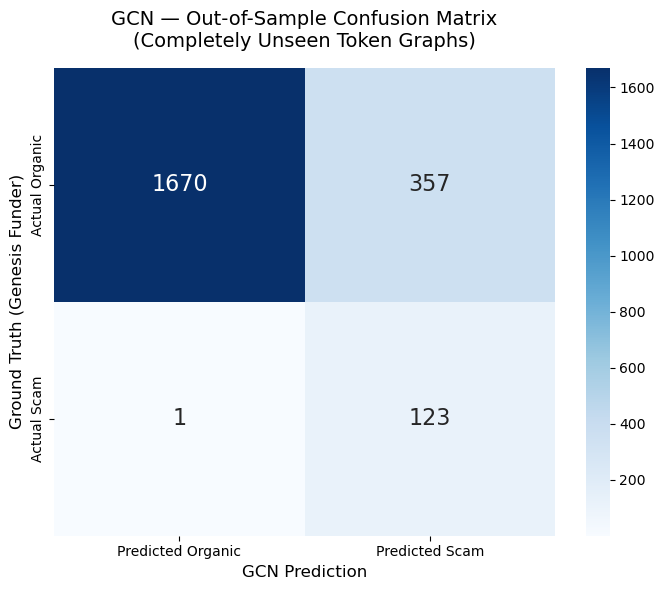


 Caught 123 out of 124 real scammers (99.2% Recall)
              precision    recall  f1-score   support

     Organic       1.00      0.82      0.90      2027
        Scam       0.26      0.99      0.41       124

    accuracy                           0.83      2151
   macro avg       0.63      0.91      0.66      2151
weighted avg       0.96      0.83      0.87      2151



In [ ]:
#GCN INFERENCE

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

gcn_model.eval()
with torch.no_grad():
    logits_gcn  = gcn_model(x_test_tensor, edge_index_test)
    gcn_preds   = (torch.softmax(logits_gcn, dim=1)[:, 1] > 0.7).numpy().astype(int)

cm_gcn = confusion_matrix(test_labels, gcn_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_gcn, annot=True, fmt='g', cmap='Blues',
            xticklabels=["Predicted Organic", "Predicted Scam"],
            yticklabels=["Actual Organic", "Actual Scam"],
            annot_kws={"size": 16})
plt.title("GCN — Out-of-Sample Confusion Matrix\n(Completely Unseen Token Graphs)", fontsize=14, pad=15)
plt.ylabel('Ground Truth (Genesis Funder)', fontsize=12)
plt.xlabel('GCN Prediction', fontsize=12)
plt.tight_layout()
plt.show()

caught_gcn = ((gcn_preds == 1) & (np.array(test_labels) == 1)).sum()
total      = sum(test_labels)
print(f"\n Caught {caught_gcn} out of {total} real scammers ({caught_gcn/max(total,1)*100:.1f}% Recall)")
print(classification_report(test_labels, gcn_preds, target_names=['Organic', 'Scam']))


GAT MODEL 

In [ ]:
#  GAT 
from torch_geometric.nn import GATConv

class ScamDetectorGAT(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, heads=4):
        super().__init__()
        torch.manual_seed(42)
        # Multi-head attention in layer 1, single head in layer 2
        self.conv1 = GATConv(num_features, hidden_channels, heads=heads, dropout=0.5)
        self.conv2 = GATConv(hidden_channels * heads, 2,    heads=1,     concat=False, dropout=0.5)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

gat_model     = ScamDetectorGAT(num_features=data.num_node_features, hidden_channels=32)
gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.0005, weight_decay=5e-4)

def train_gat():
    gat_model.train()
    gat_optimizer.zero_grad()
    out  = gat_model(data.x, data.edge_index)
    loss = criterion(out[oversampled], data.y[oversampled])
    loss.backward()
    gat_optimizer.step()
    return loss.item()

for epoch in range(1, 1200):
    loss = train_gat()
    if epoch % 100 == 0:
        print(f"GAT Epoch {epoch} | Loss: {loss:.4f}")

gat_model.eval()
with torch.no_grad():
    out  = gat_model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

y_true = data.y[data.test_mask].numpy()
y_pred = pred[data.test_mask].numpy()
print("\n── GAT Results ──")
print(classification_report(y_true, y_pred, target_names=['Organic', 'Scam']))

"""NOTE : 
The hidden dim is set to 32 (not 64) because with heads=4 the internal representation is 32×4 = 128 channels — comparable to the others at 64.
"""


GAT Epoch 100 | Loss: 0.4655
GAT Epoch 200 | Loss: 0.3654
GAT Epoch 300 | Loss: 0.3571
GAT Epoch 400 | Loss: 0.3394
GAT Epoch 500 | Loss: 0.3271
GAT Epoch 600 | Loss: 0.3183
GAT Epoch 700 | Loss: 0.3089
GAT Epoch 800 | Loss: 0.3121
GAT Epoch 900 | Loss: 0.2933
GAT Epoch 1000 | Loss: 0.2883
GAT Epoch 1100 | Loss: 0.3000

── GAT Results ──
              precision    recall  f1-score   support

     Organic       1.00      0.54      0.70      1553
        Scam       0.30      1.00      0.46       309

    accuracy                           0.61      1862
   macro avg       0.65      0.77      0.58      1862
weighted avg       0.88      0.61      0.66      1862



In [ ]:
#  Model Comparison 
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score 

results = {}
for name, mo in [("GCN", gcn_model), ("GAT", gat_model)]:
    mo.eval()
    with torch.no_grad():
        pred = mo(data.x, data.edge_index).argmax(dim=1)
    yt = data.y[data.test_mask].numpy()
    yp = pred[data.test_mask].numpy()
    results[name] = {
        "Recall (Scam)"   : recall_score(yt, yp, pos_label=1),
        "Precision (Scam)": precision_score(yt, yp, pos_label=1),
        "F1 (Scam)"       : f1_score(yt, yp, pos_label=1),
    }

import pandas as pd
print(pd.DataFrame(results).T.round(3).to_string())


     Recall (Scam)  Precision (Scam)  F1 (Scam)
GCN          0.997             0.554      0.712
GAT          0.997             0.299      0.460


In [27]:
import networkx as nx
import numpy as np
from node2vec import Node2Vec
from sklearn.neighbors import NearestNeighbors
import torch

# test graph
G_test       = nx.from_pandas_edgelist(test_edges, source='Sender', target='Receiver', create_using=nx.DiGraph())
test_wallets = list(G_test.nodes())
test_mapping = {w: i for i, w in enumerate(test_wallets)}

# graph features
pr_test   = nx.pagerank(G_test, alpha=0.85)
ind_test  = dict(G_test.in_degree())
outd_test = dict(G_test.out_degree())
cl_test   = nx.clustering(G_test.to_undirected())

send_ratio_test = {
    w: outd_test.get(w, 0) / max(ind_test.get(w, 0) + outd_test.get(w, 0), 1)
    for w in test_wallets
}
# node2vec
from nodevectors import Node2Vec
n2v_test = Node2Vec(n_components=64, walklen=20, epochs=10, threads=4)
n2v_test.fit(G_test)
emb_test = np.array([n2v_test.predict(w) for w in test_wallets])


umap_test = reducer.transform(emb_test) 

# local density
from sklearn.neighbors import NearestNeighbors
nbrs_test              = NearestNeighbors(n_neighbors=10).fit(umap_test)
dist_test, _           = nbrs_test.kneighbors(umap_test)
local_density_test     = 1 / (dist_test.mean(axis=1) + 1e-6)
avg_neighbor_dist_test = dist_test.mean(axis=1)

# edges
src_t   = test_edges['Sender'].map(test_mapping)
tgt_t   = test_edges['Receiver'].map(test_mapping)
valid_t = src_t.notna() & tgt_t.notna()
edge_index_test = torch.tensor(
    np.vstack([src_t[valid_t].astype(int).values, tgt_t[valid_t].astype(int).values]),
    dtype=torch.long)

# labels
test_labels = [1 if w in puppet_wallets else 0 for w in test_wallets]

print(f"Test graph rebuilt: {len(test_wallets):,} wallets | {G_test.number_of_edges():,} edges")
print(f"Scam wallets in test: {sum(test_labels)} / {len(test_labels)}")


Making walks... Done, T=0.00
Mapping Walk Names... Done, T=0.06
Training W2V... Done, T=1.61
Test graph rebuilt: 2,151 wallets | 2,770 edges
Scam wallets in test: 124 / 2151


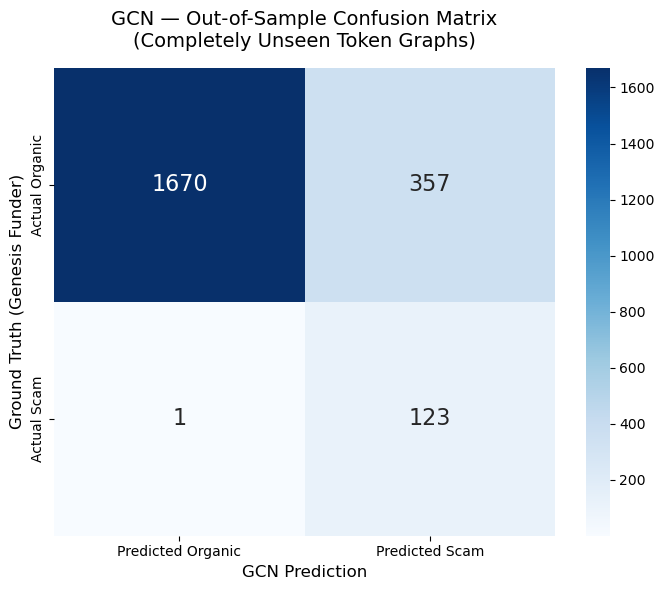


 Caught 123 out of 124 real scammers (99.2% Recall)
              precision    recall  f1-score   support

     Organic       1.00      0.82      0.90      2027
        Scam       0.26      0.99      0.41       124

    accuracy                           0.83      2151
   macro avg       0.63      0.91      0.66      2151
weighted avg       0.96      0.83      0.87      2151



In [ ]:
#  GCN: Out-of-Sample Test Inference 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

gcn_model.eval()
with torch.no_grad():
    logits_gcn  = gcn_model(x_test_tensor, edge_index_test)
    gcn_preds   = (torch.softmax(logits_gcn, dim=1)[:, 1] > 0.7).numpy().astype(int)

cm_gcn = confusion_matrix(test_labels, gcn_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_gcn, annot=True, fmt='g', cmap='Blues',
            xticklabels=["Predicted Organic", "Predicted Scam"],
            yticklabels=["Actual Organic", "Actual Scam"],
            annot_kws={"size": 16})
plt.title("GCN — Out-of-Sample Confusion Matrix\n(Completely Unseen Token Graphs)", fontsize=14, pad=15)
plt.ylabel('Ground Truth (Genesis Funder)', fontsize=12)
plt.xlabel('GCN Prediction', fontsize=12)
plt.tight_layout()
plt.show()

caught_gcn = ((gcn_preds == 1) & (np.array(test_labels) == 1)).sum()
total= sum(test_labels)
print(f"\n Caught {caught_gcn} out of {total} real scammers ({caught_gcn/max(total,1)*100:.1f}% Recall)")
print(classification_report(test_labels, gcn_preds, target_names=['Organic', 'Scam']))


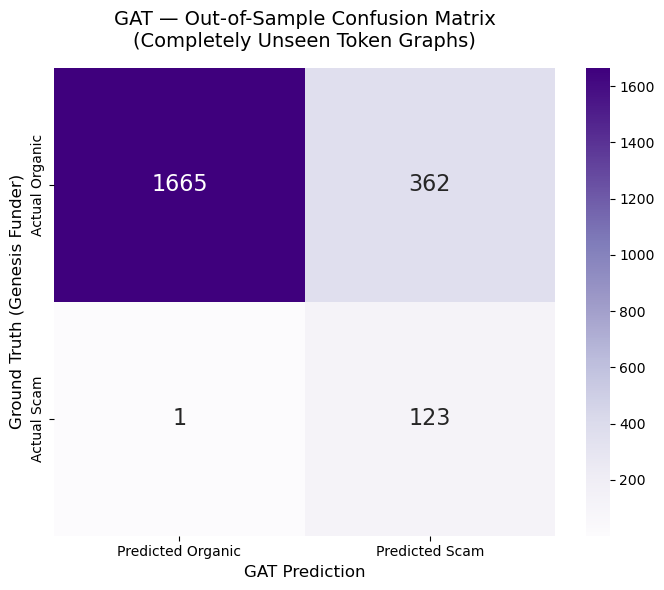


 Caught 123 out of 124 real scammers (99.2% Recall)
              precision    recall  f1-score   support

     Organic       1.00      0.82      0.90      2027
        Scam       0.25      0.99      0.40       124

    accuracy                           0.83      2151
   macro avg       0.63      0.91      0.65      2151
weighted avg       0.96      0.83      0.87      2151



In [ ]:
#  GAT: Out-of-Sample Test Inference 
gat_model.eval()
with torch.no_grad():
    logits_gat  = gat_model(x_test_tensor, edge_index_test)
    gat_preds   = (torch.softmax(logits_gat, dim=1)[:, 1] > 0.85).numpy().astype(int)

cm_gat = confusion_matrix(test_labels, gat_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_gat, annot=True, fmt='g', cmap='Purples',
            xticklabels=["Predicted Organic", "Predicted Scam"],
            yticklabels=["Actual Organic", "Actual Scam"],
            annot_kws={"size": 16})
plt.title("GAT — Out-of-Sample Confusion Matrix\n(Completely Unseen Token Graphs)", fontsize=14, pad=15)
plt.ylabel('Ground Truth (Genesis Funder)', fontsize=12)
plt.xlabel('GAT Prediction', fontsize=12)
plt.tight_layout()
plt.show()

caught_gat = ((gat_preds == 1) & (np.array(test_labels) == 1)).sum()
print(f"\n Caught {caught_gat} out of {total} real scammers ({caught_gat/max(total,1)*100:.1f}% Recall)")
print(classification_report(test_labels, gat_preds, target_names=['Organic', 'Scam']))


In [ ]:
# ── Export Results for Cross-Notebook Comparison ──────────────────────────────
import pandas as pd
import numpy as np
import json
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score

RESULTS_DIR = "../exported_data/"

# ummary metrics table (CSV) 
models = {
    "GCN"       : gcn_preds,
    "GAT"       : gat_preds,
}

rows = []
for name, preds in models.items():
    rows.append({
        "Model"            : name,
        "Notebook"         : "graphs.ipynb",
        "Accuracy_Scam"   : accuracy_score(test_labels , preds) ,
        "Recall_Scam"      : recall_score(test_labels, preds, pos_label=1),
        "Precision_Scam"   : precision_score(test_labels, preds, pos_label=1, zero_division=0),
        "F1_Scam"          : f1_score(test_labels, preds, pos_label=1),
        "Recall_Organic"   : recall_score(test_labels, preds, pos_label=0),
        "F1_Organic"       : f1_score(test_labels, preds, pos_label=0),
        "Caught"           : int(((np.array(preds)==1)&(np.array(test_labels)==1)).sum()),
        "Total_Scam"       : int(sum(test_labels)),
        "Threshold"        : 0.7,
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(RESULTS_DIR + "model_comparison.csv", index=False)
print("✓ Saved: model_comparison.csv")

# Full classification reports (JSON) 
all_reports = {}
for name, preds in models.items():
    all_reports[name] = classification_report(
        test_labels, preds,
        target_names=['Organic', 'Scam'],
        output_dict=True           # returns a dict, not a string
    )

with open(RESULTS_DIR + "classification_reports_graphs.json", "w") as f:
    json.dump(all_reports, f, indent=2)
print("✓ Saved: classification_reports_graphs.json")

# Preview 
print("\n── Summary ──")
print(summary_df.set_index("Model")[["Recall_Scam","Precision_Scam","F1_Scam","Caught","Total_Scam"]].round(3).to_string())


NameError: name 'gcn_preds' is not defined